# Ding et al. (2022): screening-to-optimization for DHA fermentation

## 0. Reproducibility card

| Item | Record |
|---|---|
| Article | Ding, J., Fu, Z., Zhu, Y., He, J., Ma, L., & Bu, D. (2022). *Enhancing docosahexaenoic acid production of Schizochytrium sp. by optimizing fermentation using central composite design*. **BMC Biotechnology, 22**, 39. |
| DOI | [10.1186/s12896-022-00769-z](https://doi.org/10.1186/s12896-022-00769-z) |
| Open-access route | [PubMed Central, PMC9737722](https://pmc.ncbi.nlm.nih.gov/articles/PMC9737722/) |
| Licence | [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) |
| Citation snapshot | 26 Crossref citations, retrieved 2026-08-01 from the DOI record |
| Reproduction level | **Level B — analytical reproduction** |
| Random seed | `20221209` |
| Core tools | `pydoe`, `numpy`, `pandas`, `scipy`, `statsmodels`, `matplotlib` |

**What is reproduced.** The 12-run Plackett–Burman (PB) screening projection, its main-effect model and tests, the 20-run rotatable circumscribed central composite design (CCD), the full quadratic model, coefficient tests, pure-error/lack-of-fit decomposition, response contours, constrained optimum, and confirmation comparison.

**What cannot be reproduced exactly.** The first-stage one-factor replicate values are available only graphically; PB randomization and any replicate-level measurements are not reported; confirmation-cultivation replicates are summarized only by a mean and conflicting SDs; and Design-Expert's full internal precision/default record is unavailable.

**Why Level B rather than A.** The row-level coded designs and responses are published, but the two PB tables assign different run numbers, Table 1's sea-salt levels conflict with the initial medium and Table 2, the CCD axial values are rounded, and one prose $R^2$ conflicts with the table and raw-data fit. Main numerical results are nevertheless reproducible to publication precision.

No new fermentation experiments are proposed or implied. Notebook-derived diagnostics and hypothetical augmentations are labelled separately from the article's results.

> **Practitioner reading guide.** Every case follows the same path: scientific context → evidence and provenance → design reconstruction → design diagnostics → article analysis → publication checks → a clearly labelled teaching extension → practitioner conclusions → reproducibility metadata. **Paper** denotes a published result, **reproduction** a notebook calculation from available evidence, and **teaching analysis** a new demonstration rather than new experimental evidence. Install the shared [`requirements.txt`](requirements.txt); Section 9 records the detailed environment used for this notebook's saved execution.


In [1]:
from importlib.metadata import version
import hashlib
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import differential_evolution, linear_sum_assignment
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from pydoe import ccdesign, pbdesign

SEED = 20221209
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=5, suppress=True)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 6)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": False})

VERSIONS = {p: version(p) for p in ["pydoe", "numpy", "pandas", "scipy", "statsmodels", "matplotlib"]}
VERSIONS

{'pydoe': '1.3.1.dev11+geca1a2598',
 'numpy': '2.3.4',
 'pandas': '3.0.0',
 'scipy': '1.16.2',
 'statsmodels': '0.14.6',
 'matplotlib': '3.11.1'}

## 1. Scientific context

The study optimized docosahexaenoic acid (DHA) production by *Schizochytrium* sp. I-F-9 in 50 mL fermentation broth held in a 250 mL shake flask for 120 h at 28 °C and 200 rpm. The experimental program was sequential:

1. one-factor source selection identified glucose and peptone;
2. a 12-run PB design screened six medium concentrations;
3. a 20-run CCD optimized the three screened factors;
4. the predicted medium was tested in a confirmation cultivation.

The **experimental unit** is a shake flask prepared at one medium setting. The PB table contains one response per setting and reports no repeat structure, so its residual is not pure error. The CCD has six independently listed centre runs, providing 5 pure-error degrees of freedom. Other CCD settings are unreplicated. No blocks are reported, and the tabulated CCD order is systematic; an actual randomized execution order is not documented.

The response is DHA production in g/L. PB factors are peptone, glucose, sodium glutamate, MgSO₄·7H₂O, KH₂PO₄, and sea salt. The CCD retains glucose, sodium glutamate, and sea salt while holding the others at low settings. This staged design is efficient only if the screening model identifies the right factors and the chosen CCD region contains a useful optimum.

## 2. Data provenance and reproduction boundary

The numeric tables below are manually transcribed from the CC BY article:

- PB coded factor settings and DHA responses: **Table 5**;
- PB physical settings used to audit run order: **Table 2**;
- PB sums of squares, F tests, and p-values: **Table 6**;
- CCD physical/coded settings and DHA responses: **Tables 3, 4, and 7**;
- published CCD predictions and coefficients: **Tables 7 and 8**;
- residual, pure-error, and lack-of-fit targets: **Table 9**.

The supplementary DOCX contains chromatograms and a calibration curve, not additional DoE rows. The article says other data are available from the corresponding author on reasonable request; this notebook uses only openly printed values.

Preserved discrepancies:

1. PB Table 1 gives sea salt as 34.4/43 g/L, while the initial medium, Table 2, and the later CCD imply 15/18.75 g/L. The latter pair is used and both source claims remain recorded.
2. PB Tables 2 and 5 contain the same 12-setting design but attach different run numbers. Responses remain paired with Table 5's coded rows.
3. Table 4 prints one sea-salt axial point as 13.728 g/L; the rotatable design gives 13.7216 g/L and Table 3 prints 13.72.
4. Results prose states $R^2=0.9598$; Table 9 states 0.9293, which agrees with the row-level fit.
5. The abstract reports confirmation SDs of 0.052 and 0.063 g/L, while the cultivation section reports 0.074 and 0.09 g/L. The latter values are used for the confirmation summary.

In [2]:
PB_NAMES = ["Peptone", "Glucose", "Sodium glutamate", "MgSO4·7H2O", "KH2PO4", "Sea salt"]
PB_CODES = list("ABCDEF")
pb_coded = pd.DataFrame(
    [
        (1,  1,  1, -1,  1,  1,  1, 6.665),
        (2, -1,  1,  1, -1,  1,  1, 6.416),
        (3,  1, -1,  1,  1, -1,  1, 7.005),
        (4, -1,  1, -1,  1,  1, -1, 6.489),
        (5, -1, -1,  1, -1,  1,  1, 7.685),
        (6, -1, -1, -1,  1, -1,  1, 8.443),
        (7,  1, -1, -1, -1,  1, -1, 6.417),
        (8,  1,  1, -1, -1, -1,  1, 7.297),
        (9,  1,  1,  1, -1, -1, -1, 5.310),
        (10,-1,  1,  1,  1, -1, -1, 4.551),
        (11, 1, -1,  1,  1,  1, -1, 6.274),
        (12,-1, -1, -1, -1, -1, -1, 7.330),
    ], columns=["run", *PB_CODES, "DHA_g_L"]
).set_index("run")

# Table 2 physical rows exactly as printed. Its row labels do not match Table 5.
pb_table2_physical = pd.DataFrame(
    [
        (1,7,125,20,9,3.125,18.75), (2,7,125,20,7.2,2.5,18.75),
        (3,5.6,100,20,9,2.5,18.75), (4,5.6,100,25,7.2,3.125,18.75),
        (5,5.6,125,25,9,2.5,15), (6,7,100,25,9,3.125,15),
        (7,5.6,125,20,9,3.125,15), (8,7,125,25,7.2,2.5,15),
        (9,7,100,20,7.2,3.125,15), (10,5.6,100,20,7.2,2.5,15),
        (11,7,100,25,9,2.5,18.75), (12,5.6,125,25,7.2,3.125,18.75),
    ], columns=["run", *PB_NAMES]
).set_index("run")

pb_levels = pd.DataFrame({
    "factor_code": PB_CODES,
    "factor": PB_NAMES,
    "unit": "g/L",
    "low_used": [5.6, 100, 20, 7.2, 2.5, 15],
    "high_used": [7, 125, 25, 9, 3.125, 18.75],
    "table1_low": [5.6, 100, 20, 7.2, 2.5, 34.4],
    "table1_high": [7, 125, 25, 9, 3.125, 43],
}).set_index("factor_code")

pb_published = pd.DataFrame({
    "SS": [0.3156, 3.44, 2.43, 0.0881, 8.33e-6, 4.25],
    "F": [1.26, 13.79, 9.74, 0.353, 0.0, 17.03],
    "p": [0.3118, 0.0138, 0.0262, 0.5783, 0.9956, 0.0091],
}, index=PB_CODES)

assert pb_coded.shape == (12, 7)
assert set(np.unique(pb_coded[PB_CODES])) == {-1, 1}
assert pb_coded.isna().sum().sum() == 0
display(pb_levels)
display(pb_coded)

,factor,unit,low_used,high_used,table1_low,table1_high
factor_code,,,,,,
A,Peptone,g/L,5.6,7.000,5.6,7.000
B,Glucose,g/L,100.0,125.000,100.0,125.000
C,Sodium glutamate,g/L,20.0,25.000,20.0,25.000
D,MgSO4·7H2O,g/L,7.2,9.000,7.2,9.000
E,KH2PO4,g/L,2.5,3.125,2.5,3.125
F,Sea salt,g/L,15.0,18.750,34.4,43.000


,A,B,C,D,E,F,DHA_g_L
run,,,,,,,
1,1,1,-1,1,1,1,6.665
2,-1,1,1,-1,1,1,6.416
3,1,-1,1,1,-1,1,7.005
4,-1,1,-1,1,1,-1,6.489
5,-1,-1,1,-1,1,1,7.685
6,-1,-1,-1,1,-1,1,8.443
7,1,-1,-1,-1,1,-1,6.417
8,1,1,-1,-1,-1,1,7.297
9,1,1,1,-1,-1,-1,5.310


In [3]:
CCD_CODES = ["A", "B", "C"]
CCD_NAMES = ["Glucose", "Sodium glutamate", "Sea salt"]
ccd = pd.DataFrame(
    [
        (1,-1,-1,-1,7.535,7.309), (2,1,-1,-1,8.105,8.015),
        (3,-1,1,-1,3.557,3.582), (4,1,1,-1,3.582,3.824),
        (5,-1,-1,1,6.270,5.662), (6,1,-1,1,6.239,5.848),
        (7,-1,1,1,6.537,6.262), (8,1,1,1,6.124,5.984),
        (9,-1.682,0,0,5.976,6.444), (10,1.682,0,0,6.756,6.805),
        (11,0,-1.682,0,5.989,6.595), (12,0,1.682,0,3.665,3.576),
        (13,0,0,-1.682,5.960,5.813), (14,0,0,1.682,5.579,6.244),
        (15,0,0,0,7.177,7.598), (16,0,0,0,7.256,7.598),
        (17,0,0,0,7.269,7.598), (18,0,0,0,8.238,7.598),
        (19,0,0,0,7.870,7.598), (20,0,0,0,7.866,7.598),
    ], columns=["run", *CCD_CODES, "DHA_g_L", "paper_predicted_g_L"]
).set_index("run")

ccd_physical_printed = pd.DataFrame(
    [
        (1,100,20,15), (2,125,20,15), (3,100,25,15), (4,125,25,15),
        (5,100,20,18.75), (6,125,20,18.75), (7,100,25,18.75), (8,125,25,18.75),
        (9,91.48,22.5,16.88), (10,133.52,22.5,16.88),
        (11,112.5,18.30,16.88), (12,112.5,26.70,16.88),
        (13,112.5,22.5,13.728), (14,112.5,22.5,20.03),
        *[(i,112.5,22.5,16.88) for i in range(15,21)],
    ], columns=["run", *CCD_NAMES]
).set_index("run")

CCD_CENTER = np.array([112.5, 22.5, 16.875])
CCD_DELTA = np.array([12.5, 2.5, 1.875])

assert ccd.shape == (20, 5)
assert (ccd[CCD_CODES] == 0).all(axis=1).sum() == 6
assert ccd.isna().sum().sum() == 0
ccd

,A,B,C,DHA_g_L,paper_predicted_g_L
run,,,,,
1,-1.000,-1.000,-1.000,7.535,7.309
2,1.000,-1.000,-1.000,8.105,8.015
3,-1.000,1.000,-1.000,3.557,3.582
4,1.000,1.000,-1.000,3.582,3.824
5,-1.000,-1.000,1.000,6.270,5.662
6,1.000,-1.000,1.000,6.239,5.848
7,-1.000,1.000,1.000,6.537,6.262
8,1.000,1.000,1.000,6.124,5.984
9,-1.682,0.000,0.000,5.976,6.444


## 3. Reconstruct the design

### 3.1 Plackett–Burman screening

A 12-run PB design can accommodate 11 two-level columns. The article assigned six real factors and described five unused columns as dummies. `pydoe.pbdesign(11)` generates an equivalent Hadamard-based design; column choice, sign, and row order are arbitrary conventions. The transformation below selects six columns and flips signs so the generated row set matches Table 5 exactly.

In [4]:
pb_full_generated = np.asarray(pbdesign(11), dtype=int)
selected_columns = [0, 1, 2, 5, 7, 10]
sign_flips = np.array([-1, 1, 1, 1, -1, -1])
pb_generated_projection = pb_full_generated[:, selected_columns] * sign_flips

published_pb_X = pb_coded[PB_CODES].to_numpy(dtype=int)
pb_hamming = np.sum(published_pb_X[:, None, :] != pb_generated_projection[None, :, :], axis=2)
pub_rows, gen_rows = linear_sum_assignment(pb_hamming)
matched_generated = pb_generated_projection[gen_rows[np.argsort(pub_rows)]]
assert np.array_equal(matched_generated, published_pb_X)

# Decode Table 5 using the physical levels supported by Table 2 and the initial medium.
lo = pb_levels["low_used"].to_numpy()
hi = pb_levels["high_used"].to_numpy()
pb_physical_from_results = (lo + hi)/2 + published_pb_X*(hi-lo)/2

# Audit the conflicting Table 2 run labels: its design set is identical after recoding.
t2 = pb_table2_physical[PB_NAMES].to_numpy(float)
t2_coded = np.rint(2*(t2-lo)/(hi-lo)-1).astype(int)
run_distance = np.sum(published_pb_X[:, None, :] != t2_coded[None, :, :], axis=2)
t5_rows, t2_rows = linear_sum_assignment(run_distance)
assert run_distance[t5_rows, t2_rows].sum() == 0

pb_mapping = pd.DataFrame({
    "table5_response_run": np.arange(1, 13),
    "matching_table2_physical_row": t2_rows[np.argsort(t5_rows)] + 1,
    "generated_pb_row": gen_rows[np.argsort(pub_rows)] + 1,
    "hamming_distance_to_generated": pb_hamming[pub_rows, gen_rows][np.argsort(pub_rows)],
}).set_index("table5_response_run")
display(pb_mapping)

pb_physical = pd.DataFrame(pb_physical_from_results, columns=PB_NAMES, index=pb_coded.index)
pb_physical["DHA_g_L"] = pb_coded["DHA_g_L"]
pb_physical

,matching_table2_physical_row,generated_pb_row,hamming_distance_to_generated
table5_response_run,,,
1,1,11,0
2,12,3,0
3,11,7,0
4,7,4,0
5,4,1,0
6,3,9,0
7,9,6,0
8,2,8,0
9,8,2,0


,Peptone,Glucose,Sodium glutamate,MgSO4·7H2O,KH2PO4,Sea salt,DHA_g_L
run,,,,,,,
1,7.0,125.0,20.0,9.0,3.125,18.75,6.665
2,5.6,125.0,25.0,7.2,3.125,18.75,6.416
3,7.0,100.0,25.0,9.0,2.500,18.75,7.005
4,5.6,125.0,20.0,9.0,3.125,15.00,6.489
5,5.6,100.0,25.0,7.2,3.125,18.75,7.685
6,5.6,100.0,20.0,9.0,2.500,18.75,8.443
7,7.0,100.0,20.0,7.2,3.125,15.00,6.417
8,7.0,125.0,20.0,7.2,2.500,18.75,7.297
9,7.0,125.0,25.0,7.2,2.500,15.00,5.310


The generated projection and Table 5 agree with zero Hamming distance. Table 2 also contains exactly the same 12 settings, but only its first row retains the same run number; the mapping table makes the permutation explicit. Because the responses are printed beside Table 5's codes, that pairing governs the analysis.

Sea salt is decoded as 15/18.75 g/L: these are Table 2's values, agree with the stated initial 15 g/L medium and the “high = 1.25 × low” rule, and flow directly into the CCD. Table 1's 34.4/43 g/L pair is preserved as a suspected transcription error rather than silently accepted.

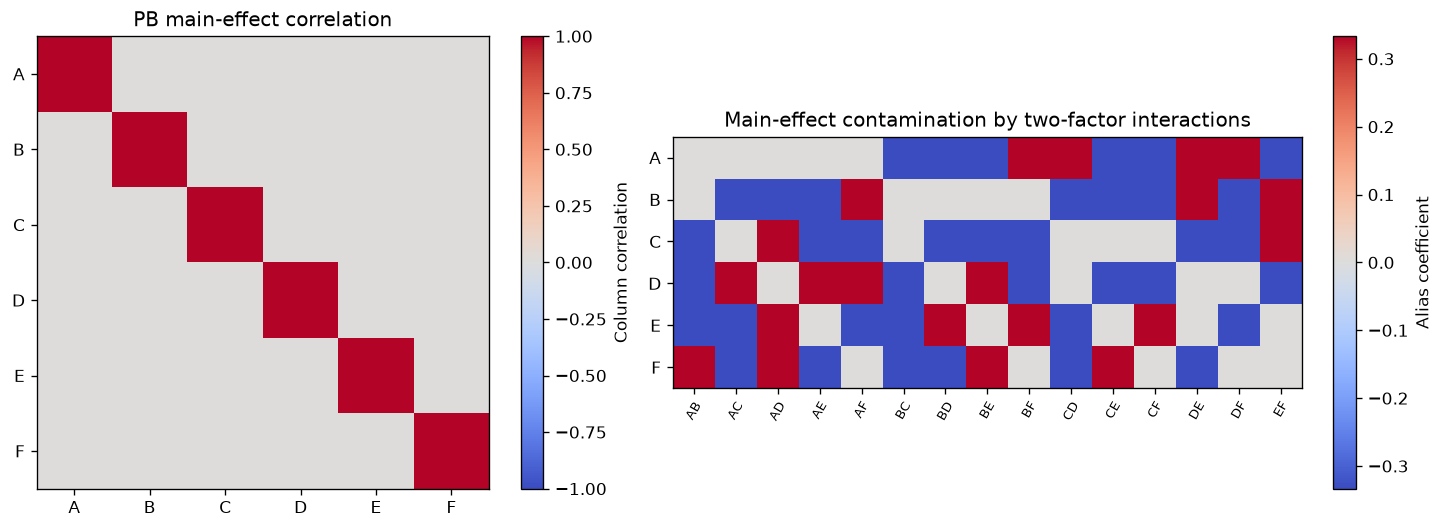

Main-effect matrix rank: 7 of 7
Maximum |main-versus-2FI alias coefficient|: 0.3333333333333333


In [5]:
# Main-effect balance/orthogonality and aliasing with all two-factor products.
interaction_names, interaction_cols = [], []
for i in range(6):
    for j in range(i+1, 6):
        interaction_names.append(PB_CODES[i] + PB_CODES[j])
        interaction_cols.append(published_pb_X[:, i] * published_pb_X[:, j])
pb_2fi = np.column_stack(interaction_cols)
main_correlation = published_pb_X.T @ published_pb_X / len(published_pb_X)
alias = published_pb_X.T @ pb_2fi / len(published_pb_X)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.3), constrained_layout=True)
im0 = axes[0].imshow(main_correlation, vmin=-1, vmax=1, cmap="coolwarm")
axes[0].set(title="PB main-effect correlation", xticks=range(6), yticks=range(6),
            xticklabels=PB_CODES, yticklabels=PB_CODES)
fig.colorbar(im0, ax=axes[0], label="Column correlation")
im1 = axes[1].imshow(alias, vmin=-1/3, vmax=1/3, cmap="coolwarm")
axes[1].set(title="Main-effect contamination by two-factor interactions",
            xticks=range(len(interaction_names)), yticks=range(6),
            xticklabels=interaction_names, yticklabels=PB_CODES)
axes[1].tick_params(axis="x", rotation=60, labelsize=8)
fig.colorbar(im1, ax=axes[1], label="Alias coefficient")
plt.show()

print("Main-effect matrix rank:", np.linalg.matrix_rank(sm.add_constant(published_pb_X)), "of 7")
print("Maximum |main-versus-2FI alias coefficient|:", np.abs(alias).max())

The PB main-effect columns are perfectly balanced and mutually orthogonal: each fitted main effect is separated from the other five. That does **not** make interactions harmless. In this six-column projection, every main effect is partially correlated ($|1/3|$) with several two-factor interactions. The screen assumes those interactions are negligible. With no repeated PB setting, its five residual degrees of freedom mix unassigned PB columns, interactions, curvature, measurement error, and flask-to-flask variation; they are not pure error.

### 3.2 Central composite optimization

For three factors, a rotatable circumscribed CCD uses $\alpha=(2^3)^{1/4}=1.68179$, eight factorial corners, six axial points, and six centres: 20 runs in total. `pydoe.ccdesign` regenerates that structure. Coded-to-physical conversion is

$$x=(X-X_0)/\Delta,$$

with centres $(112.5,22.5,16.875)$ g/L and step sizes $(12.5,2.5,1.875)$ g/L for glucose, sodium glutamate, and sea salt.

In [6]:
ccd_generated = np.asarray(ccdesign(3, center=(0, 6), alpha="rotatable", face="circumscribed"))
published_ccd_X = ccd[CCD_CODES].to_numpy(float)
ccd_distance = np.linalg.norm(published_ccd_X[:, None, :] - ccd_generated[None, :, :], axis=2)
ccd_pub_rows, ccd_gen_rows = linear_sum_assignment(ccd_distance)
matched_ccd = ccd_generated[ccd_gen_rows[np.argsort(ccd_pub_rows)]]

ccd_physical_reconstructed = CCD_CENTER + matched_ccd*CCD_DELTA
physical_difference = ccd_physical_reconstructed - ccd_physical_printed[CCD_NAMES].to_numpy()

point_type = np.where(np.all(np.isclose(published_ccd_X, 0), axis=1), "centre",
              np.where(np.any(np.abs(published_ccd_X) > 1.1, axis=1), "axial", "factorial"))
ccd_mapping = pd.DataFrame({
    "generated_row": ccd_gen_rows[np.argsort(ccd_pub_rows)] + 1,
    "point_type": point_type,
    "coded_distance": np.linalg.norm(published_ccd_X - matched_ccd, axis=1),
    "max_physical_difference_g_L": np.max(np.abs(physical_difference), axis=1),
}, index=ccd.index)

assert ccd_mapping["coded_distance"].max() < 0.0003
display(ccd_mapping)
print(f"Rotatable alpha: {np.max(np.abs(ccd_generated)):.8f}")
print(f"Largest printed-versus-generated physical discrepancy: {np.abs(physical_difference).max():.5f} g/L")

,generated_row,point_type,coded_distance,max_physical_difference_g_L
run,,,,
1,1,factorial,0.000000,0.000000
2,5,factorial,0.000000,0.000000
3,3,factorial,0.000000,0.000000
4,7,factorial,0.000000,0.000000
5,2,factorial,0.000000,0.000000
6,6,factorial,0.000000,0.000000
7,4,factorial,0.000000,0.000000
8,8,factorial,0.000000,0.000000
9,9,axial,0.000207,0.005000


Rotatable alpha: 1.68179283
Largest printed-versus-generated physical discrepancy: 0.00636 g/L


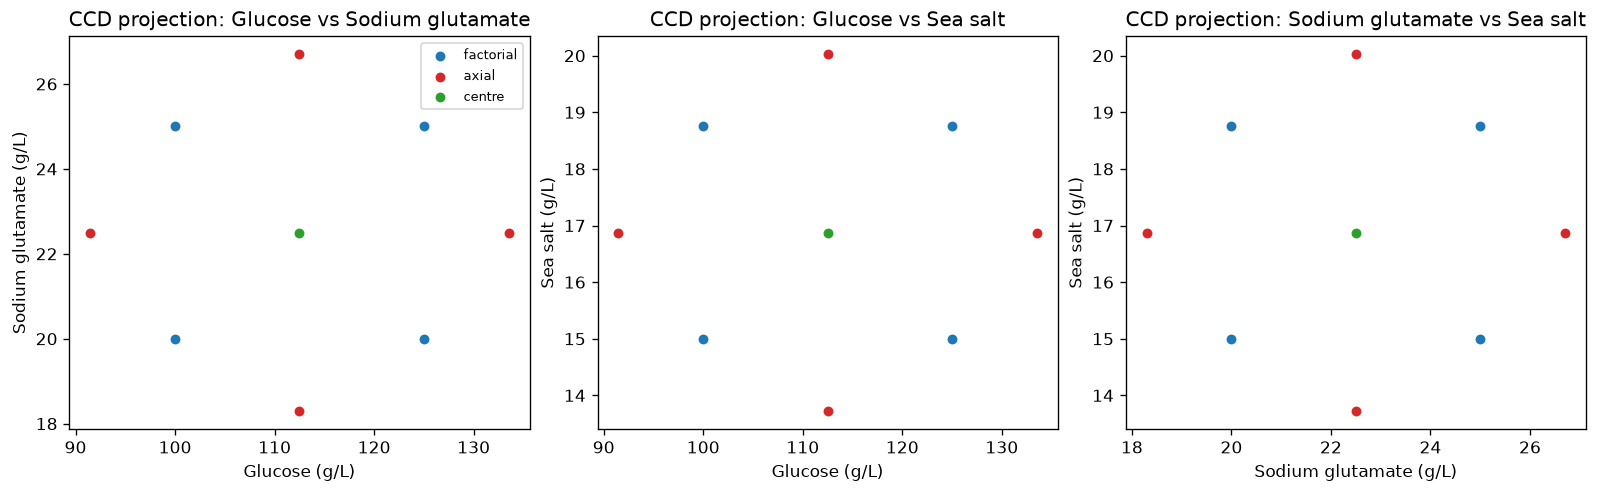

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.0), constrained_layout=True)
pairs = [(0,1), (0,2), (1,2)]
colors = {"factorial":"#1f77b4", "axial":"#d62728", "centre":"#2ca02c"}
for ax, (i,j) in zip(axes, pairs):
    for kind in ["factorial", "axial", "centre"]:
        mask = point_type == kind
        ax.scatter(ccd_physical_reconstructed[mask, i], ccd_physical_reconstructed[mask, j],
                   s=48, color=colors[kind], edgecolor="white", label=kind)
    ax.set(title=f"CCD projection: {CCD_NAMES[i]} vs {CCD_NAMES[j]}",
           xlabel=f"{CCD_NAMES[i]} (g/L)", ylabel=f"{CCD_NAMES[j]} (g/L)")
axes[0].legend(fontsize=8)
plt.show()

The generated CCD matches the coded table to within 0.00021 coded units; physical differences under 0.007 g/L are printing effects. Six coincident green centre points are genuine replication, not a plotting omission. Axial points extend beyond the $[-1,1]^3$ factorial cube to estimate curvature and make prediction variance rotatable.

## 4. Understand the design

The PB model estimates an intercept and six main effects. Its design matrix has rank 7 and condition number 1: excellent for that deliberately limited model, but unable to distinguish main effects from interaction contamination.

The CCD fits the hierarchical quadratic

$$Y=\beta_0+\sum_i\beta_i x_i+\sum_{i<j}\beta_{ij}x_ix_j+\sum_i\beta_{ii}x_i^2+\varepsilon.$$

Ten coefficients leave 10 residual degrees of freedom. The six centres give 5 pure-error degrees of freedom, leaving 5 for lack of fit. Factorial and axial points identify interactions and separate linear from quadratic effects.

In [8]:
def quadratic_matrix(x):
    x = np.atleast_2d(np.asarray(x, float))
    return np.column_stack([
        np.ones(len(x)), x,
        x[:,0]*x[:,1], x[:,0]*x[:,2], x[:,1]*x[:,2],
        x**2,
    ])

X_ccd = quadratic_matrix(published_ccd_X)
info = X_ccd.T @ X_ccd
hat = X_ccd @ np.linalg.inv(info) @ X_ccd.T
ccd_design_diagnostics = pd.Series({
    "runs": len(ccd), "parameters": X_ccd.shape[1], "rank": np.linalg.matrix_rank(X_ccd),
    "residual_df": len(ccd)-X_ccd.shape[1], "pure_error_df": 5, "lack_of_fit_df": 5,
    "condition_number": np.linalg.cond(X_ccd), "sum_leverage": np.diag(hat).sum(),
    "max_leverage": np.diag(hat).max(),
})
display(ccd_design_diagnostics.to_frame("value"))
display(pd.DataFrame({"information_eigenvalue": np.linalg.eigvalsh(info)}))

,value
runs,20.000000
parameters,10.000000
rank,10.000000
residual_df,10.000000
pure_error_df,5.000000
lack_of_fit_df,5.000000
condition_number,3.590863
sum_leverage,10.000000
max_leverage,0.669730


,information_eigenvalue
0,4.318887
1,8.000000
2,8.000000
3,8.000000
4,13.658248
5,13.658248
6,13.658248
7,16.007885
8,16.007885
9,55.688998


The full quadratic is estimable and well-conditioned. Unequal information eigenvalues are expected because the intercept and squared terms are correlated; rotatability concerns prediction variance at equal radius, not orthogonality of every polynomial column. Axial and factorial runs have higher leverage than centres, so boundary observations can influence curvature strongly.

## 5. Reproduce the article analysis

### 5.1 PB screening model

With a balanced orthogonal PB projection, each coded coefficient is half the high-minus-low effect and its one-degree-of-freedom sum of squares is $12\hat\beta_j^2$. The OLS calculation below reproduces Table 6 without relying on Design-Expert.

In [9]:
y_pb = pb_coded["DHA_g_L"].to_numpy()
pb_model = sm.OLS(y_pb, sm.add_constant(published_pb_X)).fit()
pb_reproduction = pd.DataFrame({
    "factor": PB_NAMES,
    "coded_coefficient": pb_model.params[1:],
    "high_minus_low_effect_g_L": 2*pb_model.params[1:],
    "SS_reproduced": 12*pb_model.params[1:]**2,
    "SS_published": pb_published["SS"],
    "F_reproduced": pb_model.tvalues[1:]**2,
    "F_published": pb_published["F"],
    "p_reproduced": pb_model.pvalues[1:],
    "p_published": pb_published["p"],
}, index=PB_CODES)
pb_reproduction

,factor,coded_coefficient,high_minus_low_effect_g_L,SS_reproduced,SS_published,F_reproduced,F_published,p_reproduced,p_published
A,Peptone,-0.162167,-0.324333,0.315576,0.315600,1.264893,1.260,0.311800,0.3118
B,Glucose,-0.535500,-1.071000,3.441123,3.440000,13.792710,13.790,0.013800,0.0138
C,Sodium glutamate,-0.450000,-0.900000,2.430000,2.430000,9.739927,9.740,0.026226,0.0262
D,MgSO4·7H2O,-0.085667,-0.171333,0.088065,0.088100,0.352983,0.353,0.578289,0.5783
E,KH2PO4,0.000833,0.001667,0.000008,0.000008,0.000033,0.000,0.995612,0.9956
F,Sea salt,0.595000,1.190000,4.248300,4.250000,17.028037,17.030,0.009116,0.0091


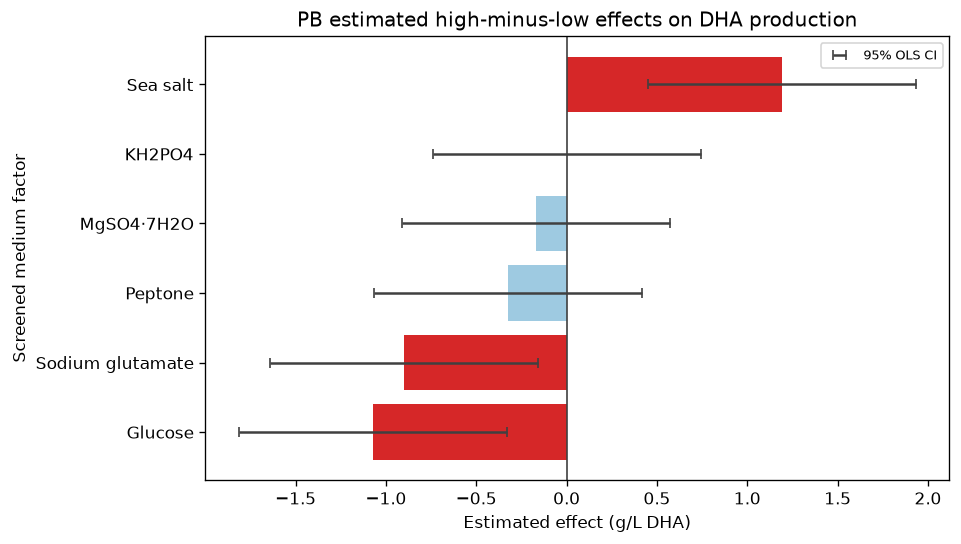

PB model F = 7.02976, p = 0.024615, R² = 0.89402


In [10]:
effects = pb_reproduction.sort_values("high_minus_low_effect_g_L")
tcrit_pb = stats.t.ppf(.975, pb_model.df_resid)
effect_halfwidth = 2*tcrit_pb*pb_model.bse[1:]
effect_halfwidth = pd.Series(effect_halfwidth, index=PB_CODES).loc[effects.index]

fig, ax = plt.subplots(figsize=(8.0, 4.8))
colors_effect = np.where(effects["p_reproduced"] < .05, "#d62728", "#9ecae1")
ax.barh(effects["factor"], effects["high_minus_low_effect_g_L"], color=colors_effect)
ax.errorbar(effects["high_minus_low_effect_g_L"], effects["factor"], xerr=effect_halfwidth,
            fmt="none", ecolor="0.25", capsize=3, label="95% OLS CI")
ax.axvline(0, color="0.25", lw=1)
ax.set(title="PB estimated high-minus-low effects on DHA production",
       xlabel="Estimated effect (g/L DHA)", ylabel="Screened medium factor")
ax.legend(fontsize=8)
plt.show()

print(f"PB model F = {pb_model.fvalue:.5f}, p = {pb_model.f_pvalue:.6f}, R² = {pb_model.rsquared:.5f}")

At the article's unadjusted 0.05 threshold, glucose (B), sodium glutamate (C), and sea salt (F) are selected. The signs are conditional high-minus-low contrasts: higher glucose and sodium glutamate reduced DHA over the screened ranges, while higher sea salt increased it. Because main effects are partially aliased with interactions, these are screening signals, not isolated causal slopes.

### 5.2 CCD quadratic model, ANOVA, and lack of fit

In [11]:
y_ccd = ccd["DHA_g_L"].to_numpy()
ccd_model = sm.OLS(y_ccd, X_ccd).fit()
TERM_NAMES = ["Intercept", "A", "B", "C", "AB", "AC", "BC", "A²", "B²", "C²"]

published_coef = pd.DataFrame({
    "coefficient": [7.6, .1071, -.8976, .1281, -.1161, -.13, 1.08, -.3442, -.8882, -.555],
    "SE": [.2141, .1421, .1421, .1421, .1856, .1856, .1856, .1383, .1383, .1383],
    "F": [np.nan, .5688, 39.93, .8132, .3912, .4903, 33.96, 6.19, 41.25, 16.11],
    "p": [np.nan, .4681, .0001, .3884, .5457, .4997, .0002, .032, .0001, .0025],
}, index=TERM_NAMES)

coef_reproduction = pd.DataFrame({
    "coefficient_reproduced": ccd_model.params,
    "coefficient_published": published_coef["coefficient"],
    "SE_reproduced": ccd_model.bse,
    "SE_published": published_coef["SE"],
    "F_reproduced": ccd_model.tvalues**2,
    "F_published": published_coef["F"],
    "p_reproduced": ccd_model.pvalues,
    "p_published_or_upper_bound": published_coef["p"],
}, index=TERM_NAMES)
coef_reproduction

,coefficient_reproduced,coefficient_published,SE_reproduced,SE_published,F_reproduced,F_published,p_reproduced,p_published_or_upper_bound
Intercept,7.597946,7.6000,0.214075,0.2141,1259.683246,NaN,7.482621e-12,NaN
A,0.107112,0.1071,0.142025,0.1421,0.568779,0.5688,4.681318e-01,0.4681
B,-0.897477,-0.8976,0.142025,0.1421,39.931472,39.9300,8.690806e-05,0.0001
C,0.128139,0.1281,0.142025,0.1421,0.814016,0.8132,3.881505e-01,0.3884
AB,-0.115875,-0.1161,0.185575,0.1856,0.389891,0.3912,5.463379e-01,0.5457
AC,-0.129875,-0.1300,0.185575,0.1856,0.489795,0.4903,4.999751e-01,0.4997
BC,1.081625,1.0800,0.185575,0.1856,33.971660,33.9600,1.663833e-04,0.0002
A²,-0.344097,-0.3442,0.138239,0.1383,6.195813,6.1900,3.203742e-02,0.0320
B²,-0.888082,-0.8882,0.138239,0.1383,41.270719,41.2500,7.593475e-05,0.0001
C²,-0.554940,-0.5550,0.138239,0.1383,16.114909,16.1100,2.460792e-03,0.0025


In [12]:
centre_mask = np.all(published_ccd_X == 0, axis=1)
centre_y = y_ccd[centre_mask]
pure_error_ss = np.sum((centre_y - centre_y.mean())**2)
lof_ss = ccd_model.ssr - pure_error_ss
lof_f = (lof_ss/5)/(pure_error_ss/5)
lof_p = stats.f.sf(lof_f, 5, 5)

anova_reproduction = pd.DataFrame({
    "SS": [ccd_model.ess, ccd_model.ssr, lof_ss, pure_error_ss, ccd_model.centered_tss],
    "df": [9, 10, 5, 5, 19],
}, index=["Model", "Residual", "Lack of fit", "Pure error", "Corrected total"])
anova_reproduction["MS"] = anova_reproduction["SS"] / anova_reproduction["df"]
anova_reproduction.loc["Model", "F"] = ccd_model.fvalue
anova_reproduction.loc["Model", "p"] = ccd_model.f_pvalue
anova_reproduction.loc["Lack of fit", "F"] = lof_f
anova_reproduction.loc["Lack of fit", "p"] = lof_p
display(anova_reproduction)

fitted_comparison = ccd[["DHA_g_L", "paper_predicted_g_L"]].copy()
fitted_comparison["reproduced_predicted_g_L"] = ccd_model.fittedvalues
fitted_comparison["paper_minus_reproduced"] = (
    fitted_comparison["paper_predicted_g_L"] - fitted_comparison["reproduced_predicted_g_L"]
)
display(fitted_comparison)
print(f"R²={ccd_model.rsquared:.6f}; adjusted R²={ccd_model.rsquared_adj:.6f}; "
      f"maximum |published−reproduced prediction|={fitted_comparison['paper_minus_reproduced'].abs().max():.6f} g/L")

,SS,df,MS,F,p
Model,36.194857,9,4.021651,14.597474,0.000122
Residual,2.755032,10,0.275503,NaN,NaN
Lack of fit,1.798469,5,0.359694,1.880136,0.252549
Pure error,0.956563,5,0.191313,NaN,NaN
Corrected total,38.949889,19,2.049994,NaN,NaN


,DHA_g_L,paper_predicted_g_L,reproduced_predicted_g_L,paper_minus_reproduced
run,,,,
1,7.535,7.309,7.308928,0.000072
2,8.105,8.015,8.014652,0.000348
3,3.557,3.582,3.582473,-0.000473
4,3.582,3.824,3.824697,-0.000697
5,6.270,5.662,5.661707,0.000293
6,6.239,5.848,5.847930,0.000070
7,6.537,6.262,6.261752,0.000248
8,6.124,5.984,5.984476,-0.000476
9,5.976,6.444,6.444290,-0.000290


R²=0.929267; adjusted R²=0.865608; maximum |published−reproduced prediction|=0.000697 g/L


The coefficient tests, overall model test, and lack-of-fit split reproduce to rounding. Lack of fit is not significant relative to centre-point pure error ($p\approx0.252$), but “not significant” is not proof that the quadratic is correct—this test has only 5 and 5 degrees of freedom. Table 9's $R^2=0.9293$ and adjusted $R^2=0.8656$ match the data; the prose value 0.9598 does not.

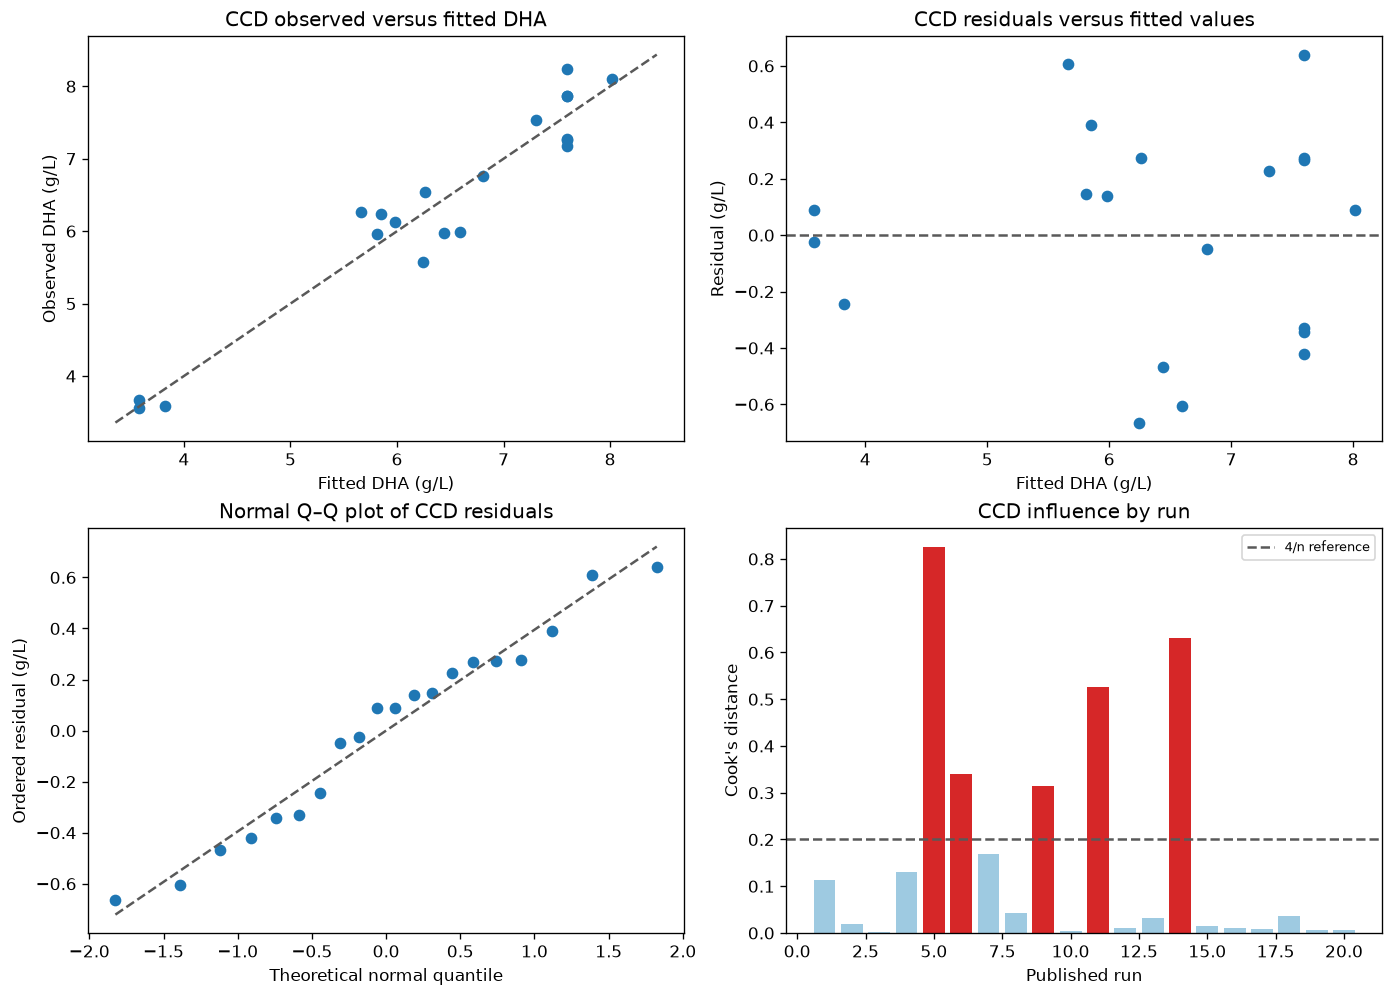

In [13]:
influence = ccd_model.get_influence()
resid = ccd_model.resid
fitted = ccd_model.fittedvalues
leverage = influence.hat_matrix_diag
cooks = influence.cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.2), constrained_layout=True)
axes[0,0].scatter(fitted, y_ccd, color="#1f77b4")
lims = [min(fitted.min(), y_ccd.min())-.2, max(fitted.max(), y_ccd.max())+.2]
axes[0,0].plot(lims, lims, "--", color="0.35")
axes[0,0].set(title="CCD observed versus fitted DHA", xlabel="Fitted DHA (g/L)", ylabel="Observed DHA (g/L)")

axes[0,1].scatter(fitted, resid, color="#1f77b4")
axes[0,1].axhline(0, color="0.35", ls="--")
axes[0,1].set(title="CCD residuals versus fitted values", xlabel="Fitted DHA (g/L)", ylabel="Residual (g/L)")

osm, osr = stats.probplot(resid, dist="norm", fit=False)
slope, intercept, *_ = stats.linregress(osm, osr)
axes[1,0].scatter(osm, osr, color="#1f77b4")
axes[1,0].plot(osm, intercept+slope*np.asarray(osm), "--", color="0.35")
axes[1,0].set(title="Normal Q–Q plot of CCD residuals", xlabel="Theoretical normal quantile", ylabel="Ordered residual (g/L)")

axes[1,1].bar(ccd.index, cooks, color=np.where(cooks > 4/len(ccd), "#d62728", "#9ecae1"))
axes[1,1].axhline(4/len(ccd), color="0.35", ls="--", label="4/n reference")
axes[1,1].set(title="CCD influence by run", xlabel="Published run", ylabel="Cook's distance")
axes[1,1].legend(fontsize=8)
plt.show()

Residual diagnostics show no decisive distributional failure in 20 observations, but their power is low. Runs 5, 14, and 11 are most influential because their residuals combine with high axial/factorial leverage. The 4/n Cook's-distance line is a diagnostic reference, not an automatic deletion rule; every row is retained.

### 5.3 Published response surfaces

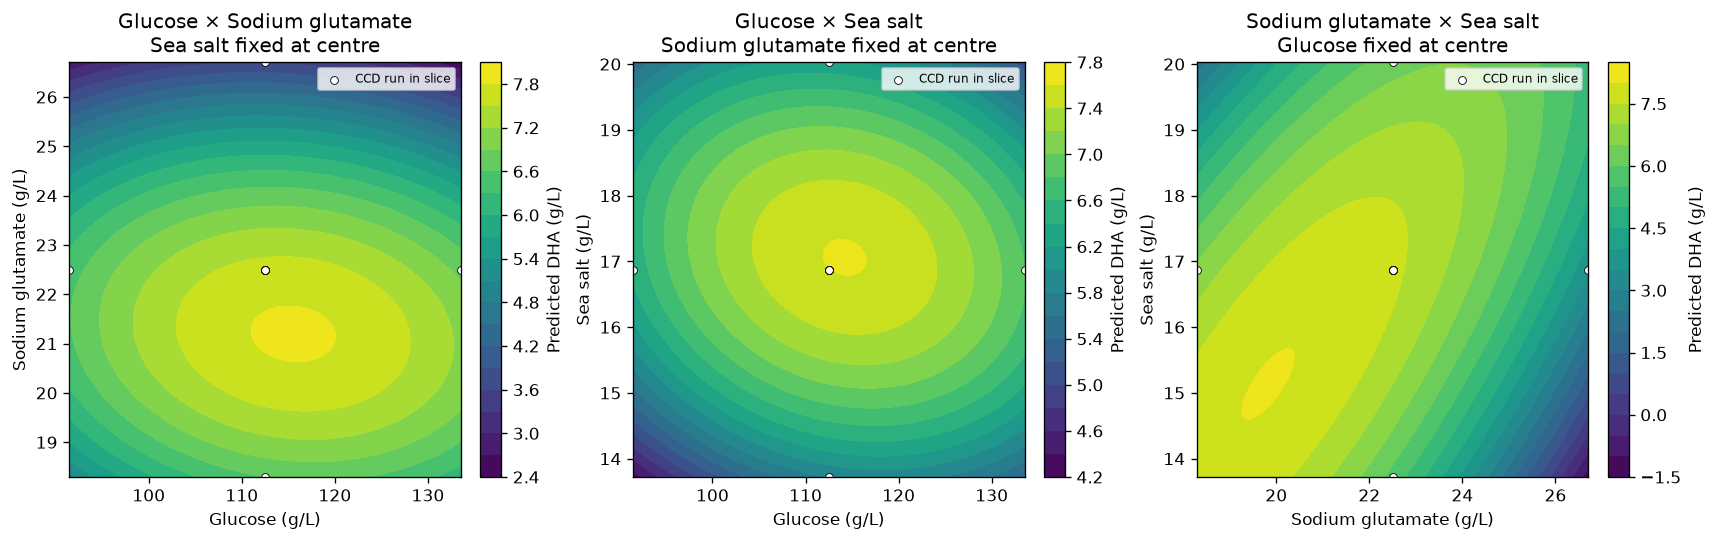

In [14]:
def predict_ccd(z):
    return ccd_model.predict(quadratic_matrix(z))

grid = np.linspace(-1.682, 1.682, 100)
pair_specs = [
    (0, 1, 2, "Glucose", "Sodium glutamate", "Sea salt fixed at centre"),
    (0, 2, 1, "Glucose", "Sea salt", "Sodium glutamate fixed at centre"),
    (1, 2, 0, "Sodium glutamate", "Sea salt", "Glucose fixed at centre"),
]
fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.4), constrained_layout=True)
for ax, (i, j, fixed, xname, yname, subtitle) in zip(axes, pair_specs):
    u, v = np.meshgrid(grid, grid)
    z = np.zeros((u.size, 3)); z[:,i] = u.ravel(); z[:,j] = v.ravel()
    pred = predict_ccd(z).reshape(u.shape)
    xphys = CCD_CENTER[i] + u*CCD_DELTA[i]
    yphys = CCD_CENTER[j] + v*CCD_DELTA[j]
    cn = ax.contourf(xphys, yphys, pred, levels=18, cmap="viridis")
    mask = np.isclose(published_ccd_X[:, fixed], 0)
    phys = CCD_CENTER + published_ccd_X*CCD_DELTA
    ax.scatter(phys[mask,i], phys[mask,j], s=22, facecolor="white", edgecolor="black", linewidth=.5,
               label="CCD run in slice")
    fig.colorbar(cn, ax=ax, label="Predicted DHA (g/L)")
    ax.set(title=f"{xname} × {yname}\n{subtitle}", xlabel=f"{xname} (g/L)", ylabel=f"{yname} (g/L)")
    ax.legend(fontsize=7)
plt.show()

These three fitted slices reproduce the logic of Figure 3. The strong sodium-glutamate curvature and sodium-glutamate × sea-salt interaction dominate the surface. White points are observed design settings lying in the displayed slice; colour is model prediction. Regions between points are interpolation by the quadratic model, not direct measurements.

### 5.4 Reproduce the constrained optimum and confirmation

The paper optimizes within the factorial cube $-1\le x_i\le1$, even though axial runs extend to $\pm1.682$. That domain choice is recoverable from its optimum: sodium glutamate lands exactly at its 20 g/L lower factorial bound.

In [15]:
def neg_prediction(z):
    return -float(predict_ccd(np.asarray(z))[0])

factorial_opt = differential_evolution(neg_prediction, [(-1,1)]*3, seed=SEED, polish=True, tol=1e-11)
axial_opt = differential_evolution(neg_prediction, [(-1.682,1.682)]*3, seed=SEED, polish=True, tol=1e-11)

factorial_phys = CCD_CENTER + factorial_opt.x*CCD_DELTA
axial_phys = CCD_CENTER + axial_opt.x*CCD_DELTA
opt_prediction = ccd_model.get_prediction(quadratic_matrix(factorial_opt.x)).summary_frame(alpha=.05).iloc[0]

optimization = pd.DataFrame({
    "domain": ["Paper's factorial cube", "Full axial-coordinate cube"],
    "glucose_g_L": [factorial_phys[0], axial_phys[0]],
    "sodium_glutamate_g_L": [factorial_phys[1], axial_phys[1]],
    "sea_salt_g_L": [factorial_phys[2], axial_phys[2]],
    "predicted_DHA_g_L": [-factorial_opt.fun, -axial_opt.fun],
}, index=["reproduced_paper_domain", "notebook_sensitivity"])
display(optimization)
display(opt_prediction.to_frame("value"))

confirmation = pd.Series({
    "paper_predicted_DHA_g_L": 8.10,
    "reproduced_predicted_DHA_g_L": -factorial_opt.fun,
    "confirmed_mean_DHA_g_L": 8.33,
    "confirmed_SD_section_g_L": 0.074,
    "initial_mean_DHA_g_L": 6.18,
    "reported_improvement_pct": 34.73,
    "improvement_from_rounded_means_pct": 100*(8.33-6.18)/6.18,
})
confirmation.to_frame("value")

,domain,glucose_g_L,sodium_glutamate_g_L,sea_salt_g_L,predicted_DHA_g_L
reproduced_paper_domain,Paper's factorial cube,118.714004,20.000000,15.155132,8.100065
notebook_sensitivity,Full axial-coordinate cube,119.927511,19.326293,14.641419,8.123112


,value
mean,8.100065
mean_se,0.325550
mean_ci_lower,7.374694
mean_ci_upper,8.825435
obs_ci_lower,6.723864
obs_ci_upper,9.476265


,value
paper_predicted_DHA_g_L,8.100000
reproduced_predicted_DHA_g_L,8.100065
confirmed_mean_DHA_g_L,8.330000
confirmed_SD_section_g_L,0.074000
initial_mean_DHA_g_L,6.180000
reported_improvement_pct,34.730000
improvement_from_rounded_means_pct,34.789644


The paper-domain optimization reproduces approximately 118.71 g/L glucose, 20.00 g/L sodium glutamate, 15.16 g/L sea salt, and 8.10 g/L predicted DHA. It lies inside the factorial cube and therefore inside its convex hull: this is interpolation, not extrapolation. The confirmed 8.33 g/L lies inside the regression's wide 95% prediction interval. The 34.73% improvement differs slightly from the value calculated from rounded 8.33 and 6.18 means.

Allowing the optimizer to use the full axial-coordinate cube moves below the paper's low sodium-glutamate and sea-salt bounds and changes the optimum. That is a **notebook sensitivity analysis**, not a recommended recipe: axial points help fit curvature, but changing operational constraints requires scientific justification.

## 6. Validate against the paper

The compact table uses absolute and relative differences where both values are scalar. P-values printed as `<0.0001` are validated against that bound rather than treated as exactly 0.0001.

In [16]:
validation_rows = [
    ("PB model F", 7.03, pb_model.fvalue, .01, "rounding"),
    ("PB model p", .0246, pb_model.f_pvalue, .0001, "rounding"),
    ("PB glucose p", .0138, pb_model.pvalues[2], .0001, "rounding"),
    ("PB sea-salt p", .0091, pb_model.pvalues[6], .0001, "rounding"),
    ("CCD model F", 14.59, ccd_model.fvalue, .02, "rounding"),
    ("CCD R² (Table 9)", .9293, ccd_model.rsquared, .0001, "agrees with table"),
    ("CCD adjusted R²", .8656, ccd_model.rsquared_adj, .0001, "rounding"),
    ("CCD R² (results prose)", .9598, ccd_model.rsquared, .0001, "source inconsistency"),
    ("Residual SS", 2.76, ccd_model.ssr, .01, "rounding"),
    ("Pure-error SS", .956, pure_error_ss, .002, "rounding"),
    ("Lack-of-fit F", 1.88, lof_f, .01, "rounding"),
    ("Lack-of-fit p", .2521, lof_p, .0006, "reported SS/software rounding"),
    ("Optimal glucose (g/L)", 118.71, factorial_phys[0], .03, "optimizer/printed coefficients"),
    ("Optimal sodium glutamate (g/L)", 20.00, factorial_phys[1], .01, "active lower bound"),
    ("Optimal sea salt (g/L)", 15.16, factorial_phys[2], .03, "optimizer/printed coefficients"),
    ("Optimal predicted DHA (g/L)", 8.10, -factorial_opt.fun, .01, "rounding"),
]
validation = pd.DataFrame(validation_rows, columns=["target", "published", "reproduced", "tolerance", "explanation"])
validation["absolute_difference"] = (validation["reproduced"]-validation["published"]).abs()
validation["relative_difference"] = validation["absolute_difference"] / validation["published"].abs()
validation["within_tolerance"] = validation["absolute_difference"] <= validation["tolerance"]
validation[["target", "published", "reproduced", "absolute_difference", "relative_difference",
            "tolerance", "within_tolerance", "explanation"]]

,target,published,reproduced,absolute_difference,relative_difference,tolerance,within_tolerance,explanation
0,PB model F,7.0300,7.029764,2.360402e-04,3.357614e-05,0.0100,True,rounding
1,PB model p,0.0246,0.024615,1.488996e-05,6.052829e-04,0.0001,True,rounding
2,PB glucose p,0.0138,0.013800,3.254396e-07,2.358258e-05,0.0001,True,rounding
3,PB sea-salt p,0.0091,0.009116,1.595818e-05,1.753646e-03,0.0001,True,rounding
4,CCD model F,14.5900,14.597474,7.473723e-03,5.122497e-04,0.0200,True,rounding
5,CCD R² (Table 9),0.9293,0.929267,3.273136e-05,3.522152e-05,0.0001,True,agrees with table
6,CCD adjusted R²,0.8656,0.865608,7.810419e-06,9.023127e-06,0.0001,True,rounding
7,CCD R² (results prose),0.9598,0.929267,3.053273e-02,3.181156e-02,0.0001,False,source inconsistency
8,Residual SS,2.7600,2.755032,4.967965e-03,1.799987e-03,0.0100,True,rounding
9,Pure-error SS,0.9560,0.956563,5.633333e-04,5.892608e-04,0.0020,True,rounding


Every primary target agrees within printing tolerance except the prose $R^2=0.9598$. The raw 20 responses reproduce Table 9's 0.9293, so the prose value is best treated as an article error. Published row predictions differ from the refit by at most about 0.001 g/L because the table and coded axial levels are rounded.

## 7. Go beyond the paper

### 7.1 Screening multiplicity and interaction vulnerability

The paper applies six unadjusted 0.05 tests. This is common in exploratory screening but makes selection threshold-dependent. Bonferroni and Benjamini–Hochberg (BH) results below are sensitivity analyses, not replacements for scientific judgment. A hypothetical full foldover appends the sign-reversed 12-run PB matrix; it would cancel all main-effect/two-factor-interaction correlations in this projection, at the cost of 12 new experiments. No such observations are invented here.

In [17]:
raw_p = pb_model.pvalues[1:]
bonf_reject, bonf_p, _, _ = multipletests(raw_p, alpha=.05, method="bonferroni")
bh_reject, bh_p, _, _ = multipletests(raw_p, alpha=.05, method="fdr_bh")
multiplicity = pd.DataFrame({
    "factor": PB_NAMES, "raw_p": raw_p, "raw_p_lt_0.05": raw_p < .05,
    "Bonferroni_adjusted_p": bonf_p, "Bonferroni_selected": bonf_reject,
    "BH_adjusted_p": bh_p, "BH_selected": bh_reject,
}, index=PB_CODES)
display(multiplicity)

foldover_main = np.vstack([published_pb_X, -published_pb_X])
foldover_2fi = np.vstack([pb_2fi, pb_2fi])
foldover_alias = foldover_main.T @ foldover_2fi / len(foldover_main)
alias_comparison = pd.Series({
    "published_12_run_max_abs_alias": np.abs(alias).max(),
    "hypothetical_24_run_foldover_max_abs_alias": np.abs(foldover_alias).max(),
})
alias_comparison.to_frame("value")

,factor,raw_p,raw_p_lt_0.05,Bonferroni_adjusted_p,Bonferroni_selected,BH_adjusted_p,BH_selected
A,Peptone,0.311800,False,1.000000,False,0.467701,False
B,Glucose,0.013800,True,0.082798,False,0.041399,True
C,Sodium glutamate,0.026226,True,0.157356,False,0.052452,False
D,MgSO4·7H2O,0.578289,False,1.000000,False,0.693946,False
E,KH2PO4,0.995612,False,1.000000,False,0.995612,False
F,Sea salt,0.009116,True,0.054696,False,0.041399,True


,value
published_12_run_max_abs_alias,0.333333
hypothetical_24_run_foldover_max_abs_alias,0.000000


Unadjusted testing selects B, C, and F; BH retains B and F; Bonferroni retains none at 0.05. This instability does not prove the article's screen wrong—it shows why PB selections should be treated as candidates for follow-up rather than definitive mechanistic findings. The hypothetical foldover removes two-factor contamination of main effects, while the actual CCD instead follows three selected factors in depth.

### 7.2 Designed leave-one-out prediction

A random train/test split would discard the CCD's structure and be unstable at $n=20$. For a linear-in-parameters quadratic model, leave-one-out residuals are obtained exactly as $e_i/(1-h_i)$. PRESS and predicted $R^2=1-PRESS/SST$ assess how well each run is predicted without using itself.

,value
ordinary_R2,0.929267
adjusted_R2,0.865608
PRESS,15.011343
LOOCV_RMSE_g_L,0.866353
predicted_R2,0.614599


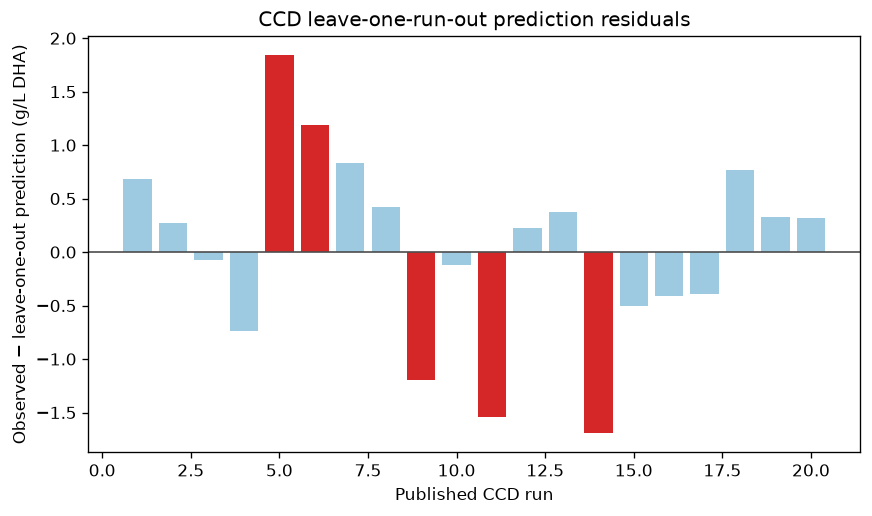

In [18]:
press_residuals = resid/(1-leverage)
press = np.sum(press_residuals**2)
predicted_r2 = 1 - press/ccd_model.centered_tss
loocv = pd.Series({
    "ordinary_R2": ccd_model.rsquared,
    "adjusted_R2": ccd_model.rsquared_adj,
    "PRESS": press,
    "LOOCV_RMSE_g_L": np.sqrt(np.mean(press_residuals**2)),
    "predicted_R2": predicted_r2,
})
display(loocv.to_frame("value"))

fig, ax = plt.subplots(figsize=(8.3, 4.5))
ax.bar(ccd.index, press_residuals, color=np.where(np.abs(press_residuals) > 1, "#d62728", "#9ecae1"))
ax.axhline(0, color="0.3", lw=1)
ax.set(title="CCD leave-one-run-out prediction residuals", xlabel="Published CCD run",
       ylabel="Observed − leave-one-out prediction (g/L DHA)")
plt.show()

Predicted $R^2$ is materially lower than ordinary $R^2$. The surface explains the fitted sample well but predicts omitted high-leverage runs less impressively. That gap is a more realistic warning for practitioners than reporting only the in-sample optimum.

## 8. Practitioner conclusions

- **What sequential DoE made possible:** PB reduced six medium variables to three in 12 runs; the CCD then estimated linear effects, all pairwise interactions, curvature, pure error, and an interpolated optimum in 20 runs. One-factor-at-a-time work would miss the strong sodium-glutamate × sea-salt interaction and cannot estimate a joint quadratic surface efficiently.
- **What the screen supports:** B, C, and F are unadjusted screening signals. PB orthogonality protects them from other main effects, not from two-factor interactions or multiplicity. Treat screening as model-dependent prioritization.
- **What the CCD supports:** all ten hierarchical quadratic coefficients are estimable. B, BC, A², B², and C² have the reported small p-values; insignificant linear A/C terms remain because hierarchy and curvature require them.
- **Where prediction is credible:** the paper's optimum is inside the factorial cube and hence interpolated. Confidence remains limited by six centre replicates, unreplicated boundaries, a modest leave-one-out predicted $R^2$, and uncertain transfer from shake flask to production scale.
- **Design versus model limitations:** PB aliasing is a design limitation; polynomial misspecification and the optimizer's domain are model/use limitations. Non-significant lack of fit does not certify the model.
- **Replication lesson:** six centre flasks estimate pure error. Repeated analytical measurements from one flask would not provide the same information.
- **Avoidable mistakes:** do not pair Table 2's run labels directly with Table 5 responses, do not use Table 1's sea-salt levels without auditing the contradiction, do not delete influential CCD runs automatically, and do not optimize outside declared bounds merely because the polynomial permits it.

## 9. Reproducibility metadata

Checksums cover stable CSV serializations of the manually transcribed PB and CCD response tables. The final cell records the live interpreter, dependency versions, seed, and execution date.

In [19]:
def dataframe_sha256(frame):
    return hashlib.sha256(frame.to_csv(index=True, lineterminator="\n").encode("utf-8")).hexdigest()

metadata = pd.Series({
    "python": platform.python_version(),
    **{f"package_{k}": v for k, v in VERSIONS.items()},
    "random_seed": SEED,
    "execution_date_utc": pd.Timestamp.now(tz="UTC").date().isoformat(),
    "pb_table5_sha256": dataframe_sha256(pb_coded),
    "ccd_table7_sha256": dataframe_sha256(ccd),
    "article_doi": "10.1186/s12896-022-00769-z",
    "reproduction_level": "B — analytical reproduction",
})
metadata.to_frame("value")

,value
python,3.13.2
package_pydoe,1.3.1.dev11+geca1a2598
package_numpy,2.3.4
package_pandas,3.0.0
package_scipy,1.16.2
package_statsmodels,0.14.6
package_matplotlib,3.11.1
random_seed,20221209
execution_date_utc,2026-08-01
pb_table5_sha256,5ac4016cde36d367c04353137e99c58bde23e8069cc843...
